In [1]:
import json as _json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    f1_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay
)

import joblib

RANDOM_STATE = 42


In [2]:
raw = pd.read_csv("../data/raw/diabetic_data.csv")
raw = raw.replace("?", np.nan)
raw = raw[raw["gender"] != "Unknown/Invalid"].copy()
raw["readmitted_30"] = (raw["readmitted"] == "<30").astype(int)

X_raw = raw.drop(columns=["readmitted_30"])
y_raw = raw["readmitted_30"]
groups_raw = raw["patient_nbr"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(sgkf.split(X_raw, y_raw, groups=groups_raw))

patient_nbr_train = raw.iloc[train_idx]["patient_nbr"].reset_index(drop=True)

TARGET = "readmitted_30"
train_df = pd.read_csv("../data/processed/train_clean_selected.csv")
test_df = pd.read_csv("../data/processed/test_clean_selected.csv")

assert len(train_df) == len(patient_nbr_train), "Row count mismatch -- check RANDOM_STATE/cleaning steps."
reconstructed_target = raw.iloc[train_idx][TARGET].reset_index(drop=True)
assert (reconstructed_target.values == train_df[TARGET].values).all(), "Target mismatch -- do not proceed."
print("PASS: patient_nbr aligns with train_clean_selected.csv row order.")

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")


PASS: patient_nbr aligns with train_clean_selected.csv row order.
X_train: (81526, 45), X_test: (20237, 45)


In [5]:
import os
print("cwd:", os.getcwd())
print()
for d in ["../models", "../results"]:
    print(f"{d}:", os.listdir(d) if os.path.exists(d) else "DOES NOT EXIST")

cwd: C:\Users\Jeric\Documents\MachineLearning_Asgm\notebooks

../models: ['xgboost_tuned.joblib']
../results: ['lr_rf_tuned_summary.json', 'xgboost_tuned_summary.json']


In [8]:
lr_tuned = joblib.load("../models/logistic_regression_tuned.joblib")
rf_tuned = joblib.load("../models/random_forest_tuned.joblib")
xgb_tuned = joblib.load("../models/xgboost_tuned.joblib")

print("Loaded three tuned base models.")
print("LR params: ", {k: v for k, v in lr_tuned.get_params().items() if k in ["C", "penalty", "l1_ratio", "class_weight", "solver"]})
print("RF params: ", {k: v for k, v in rf_tuned.get_params().items() if k in ["n_estimators", "max_depth", "max_features", "min_samples_leaf", "min_samples_split", "class_weight"]})
print("XGB params:", {k: v for k, v in xgb_tuned.get_params().items() if k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "scale_pos_weight"]})


Loaded three tuned base models.
LR params:  {'C': np.float64(0.011526449540315618), 'class_weight': 'balanced', 'l1_ratio': np.float64(0.18182496720710062), 'penalty': 'l1', 'solver': 'saga'}
RF params:  {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 9, 'min_samples_split': 15, 'n_estimators': 341}
XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 10, 'scale_pos_weight': np.float64(7.893422057379731), 'subsample': 0.8}


In [9]:
with open("../results/xgboost_tuned_summary.json") as f:
    xgb_summary = _json.load(f)
with open("../results/lr_rf_tuned_summary.json") as f:
    lr_rf_summary = _json.load(f)

lr_summary = lr_rf_summary["logistic_regression"]
rf_summary = lr_rf_summary["random_forest"]

comparison_rows = []
for name, s in [("Logistic Regression", lr_summary), ("Random Forest", rf_summary), ("XGBoost", xgb_summary)]:
    comparison_rows.append({
        "Model": name,
        "Test PR-AUC": s.get("test_prauc", s.get("test_pr_auc")),
        "Test ROC-AUC": s.get("test_roc_auc"),
        "Precision (tuned thr)": s.get("test_precision_tuned"),
        "Recall (tuned thr)": s.get("test_recall_tuned"),
        "F1 (tuned thr)": s.get("test_f1_tuned"),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Test PR-AUC", ascending=False)
print(comparison_df.to_string(index=False))


              Model  Test PR-AUC  Test ROC-AUC  Precision (tuned thr)  Recall (tuned thr)  F1 (tuned thr)
      Random Forest     0.194896      0.631024               0.134320            0.733790        0.227074
            XGBoost     0.193615      0.629698               0.119007            0.914612        0.210609
Logistic Regression     0.191502      0.626624               0.128833            0.790411        0.221554


In [10]:
def evaluate_voting_cv(model_dict, X, y, groups, cv):
    """Manual grouped CV: for each fold, fit fresh clones of each named model on the fold's
    training portion, average their predict_proba on the fold's validation portion (soft
    voting), and score PR-AUC. Returns the list of per-fold PR-AUC scores."""
    fold_scores = []
    for fold_i, (fit_idx, val_idx) in enumerate(cv.split(X, y, groups=groups)):
        X_fit, X_val = X.iloc[fit_idx], X.iloc[val_idx]
        y_fit, y_val = y.iloc[fit_idx], y.iloc[val_idx]

        probas = []
        for name, model in model_dict.items():
            m = clone(model)
            m.fit(X_fit, y_fit)
            probas.append(m.predict_proba(X_val)[:, 1])

        voted_proba = np.mean(probas, axis=0)
        score = average_precision_score(y_val, voted_proba)
        fold_scores.append(score)

    return fold_scores


candidate_sets = {
    "LR + RF": {"lr": lr_tuned, "rf": rf_tuned},
    "LR + XGB": {"lr": lr_tuned, "xgb": xgb_tuned},
    "RF + XGB": {"rf": rf_tuned, "xgb": xgb_tuned},
    "LR + RF + XGB": {"lr": lr_tuned, "rf": rf_tuned, "xgb": xgb_tuned},
}

voting_cv_results = {}
for name, models in candidate_sets.items():
    scores = evaluate_voting_cv(models, X_train, y_train, patient_nbr_train, cv)
    voting_cv_results[name] = scores
    print(f"{name:20s} -> mean PR-AUC = {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LR + RF              -> mean PR-AUC = 0.1954 (+/- 0.0081)


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LR + XGB             -> mean PR-AUC = 0.1948 (+/- 0.0081)
RF + XGB             -> mean PR-AUC = 0.1949 (+/- 0.0080)


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


LR + RF + XGB        -> mean PR-AUC = 0.1957 (+/- 0.0082)


In [ ]:
from sklearn.model_selection import cross_val_score

stacking_cv_results = {}
for name, models in candidate_sets.items():
    estimators = [(k, clone(v)) for k, v in models.items()]
    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5,  # NOT grouped -- documented limitation, see markdown above
        n_jobs=-1,
    )
    scores = cross_val_score(stack, X_train, y_train, cv=5, scoring="average_precision", n_jobs=-1)
    stacking_cv_results[name] = scores
    print(f"{name:20s} (stacking) -> mean PR-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")


LR + RF              (stacking) -> mean PR-AUC = 0.1949 (+/- 0.0085)


In [12]:
all_results = []
for name, scores in voting_cv_results.items():
    all_results.append({"Combination": name, "Method": "Soft Voting", "Mean CV PR-AUC": np.mean(scores), "Std": np.std(scores)})
for name, scores in stacking_cv_results.items():
    all_results.append({"Combination": name, "Method": "Stacking (ungrouped CV)", "Mean CV PR-AUC": np.mean(scores), "Std": np.std(scores)})

results_df = pd.DataFrame(all_results).sort_values("Mean CV PR-AUC", ascending=False)
print(results_df.to_string(index=False))

best_row = results_df.iloc[0]
print(f"\nSelected: {best_row['Combination']} via {best_row['Method']} (CV PR-AUC = {best_row['Mean CV PR-AUC']:.4f})")


  Combination                  Method  Mean CV PR-AUC      Std
LR + RF + XGB             Soft Voting        0.195742 0.008150
      LR + RF             Soft Voting        0.195426 0.008055
      LR + RF Stacking (ungrouped CV)        0.194934 0.008455
     RF + XGB             Soft Voting        0.194878 0.007961
LR + RF + XGB Stacking (ungrouped CV)        0.194839 0.008416
     LR + XGB             Soft Voting        0.194760 0.008076
     RF + XGB Stacking (ungrouped CV)        0.194728 0.007584
     LR + XGB Stacking (ungrouped CV)        0.194097 0.008138

Selected: LR + RF + XGB via Soft Voting (CV PR-AUC = 0.1957)


In [13]:
# ---- Set these based on Section 6's results ----
FINAL_COMBINATION = best_row["Combination"]   # e.g. "LR + RF + XGB" -- override manually if the parsimony check in Section 6 suggests a simpler choice
FINAL_METHOD = best_row["Method"]             # "Soft Voting" or "Stacking (ungrouped CV)"

final_models = candidate_sets[FINAL_COMBINATION]
estimators = [(k, clone(v)) for k, v in final_models.items()]

if FINAL_METHOD == "Soft Voting":
    final_ensemble = VotingClassifier(estimators=estimators, voting="soft")
else:
    final_ensemble = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5,
        n_jobs=-1,
    )

final_ensemble.fit(X_train, y_train)
print(f"Final ensemble fitted: {FINAL_COMBINATION} via {FINAL_METHOD}")


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Final ensemble fitted: LR + RF + XGB via Soft Voting


In [14]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
fit_idx, val_idx = next(gss.split(X_train, y_train, groups=patient_nbr_train))
X_fit, X_val = X_train.iloc[fit_idx], X_train.iloc[val_idx]
y_fit, y_val = y_train.iloc[fit_idx], y_train.iloc[val_idx]

val_ensemble = clone(final_ensemble)
val_ensemble.fit(X_fit, y_fit)
val_proba = val_ensemble.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)
beta = 2
f2_scores = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-12)
best_idx = np.argmax(f2_scores[:-1])
ensemble_threshold = thresholds[best_idx]

print(f"Ensemble threshold maximising F2: {ensemble_threshold:.4f} "
      f"(precision={precisions[best_idx]:.4f}, recall={recalls[best_idx]:.4f})")


C:\Users\Jeric\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Ensemble threshold maximising F2: 0.4555 (precision=0.1377, recall=0.7502)


=== Final ensemble: LR + RF + XGB (Soft Voting) ===

--- Default threshold (0.5) ---
PR-AUC:    0.1953
ROC-AUC:   0.6304
Precision: 0.1672
Recall:    0.4744
F1:        0.2472

--- Tuned threshold (0.455) ---
PR-AUC:    0.1953
ROC-AUC:   0.6304
Precision: 0.1347
Recall:    0.7342
F1:        0.2276



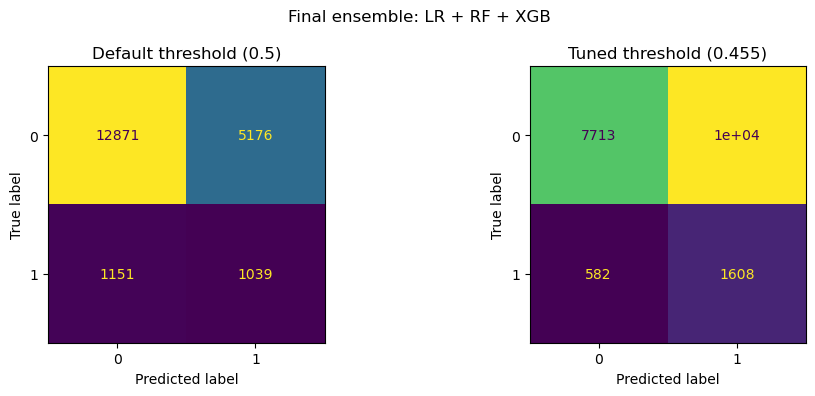

In [15]:
# ---- Final held-out test-set evaluation (touched once) ----
test_proba = final_ensemble.predict_proba(X_test)[:, 1]
test_pred_default = (test_proba >= 0.5).astype(int)
test_pred_tuned = (test_proba >= ensemble_threshold).astype(int)

def report_metrics(y_true, y_pred, y_proba, label):
    print(f"--- {label} ---")
    print(f"PR-AUC:    {average_precision_score(y_true, y_proba):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1:        {f1_score(y_true, y_pred):.4f}")
    print()

print(f"=== Final ensemble: {FINAL_COMBINATION} ({FINAL_METHOD}) ===\n")
report_metrics(y_test, test_pred_default, test_proba, "Default threshold (0.5)")
report_metrics(y_test, test_pred_tuned, test_proba, f"Tuned threshold ({ensemble_threshold:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_default)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Default threshold (0.5)")
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred_tuned)).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Tuned threshold ({ensemble_threshold:.3f})")
plt.suptitle(f"Final ensemble: {FINAL_COMBINATION}")
plt.tight_layout()
plt.show()


In [16]:
final_comparison_rows = comparison_df.to_dict("records")
final_comparison_rows.append({
    "Model": f"Ensemble ({FINAL_COMBINATION}, {FINAL_METHOD})",
    "Test PR-AUC": float(average_precision_score(y_test, test_proba)),
    "Test ROC-AUC": float(roc_auc_score(y_test, test_proba)),
    "Precision (tuned thr)": float(precision_score(y_test, test_pred_tuned)),
    "Recall (tuned thr)": float(recall_score(y_test, test_pred_tuned)),
    "F1 (tuned thr)": float(f1_score(y_test, test_pred_tuned)),
})

full_comparison_df = pd.DataFrame(final_comparison_rows).sort_values("Test PR-AUC", ascending=False)
print(full_comparison_df.to_string(index=False))


                                Model  Test PR-AUC  Test ROC-AUC  Precision (tuned thr)  Recall (tuned thr)  F1 (tuned thr)
Ensemble (LR + RF + XGB, Soft Voting)     0.195269      0.630413               0.134651            0.734247        0.227569
                        Random Forest     0.194896      0.631024               0.134320            0.733790        0.227074
                              XGBoost     0.193615      0.629698               0.119007            0.914612        0.210609
                  Logistic Regression     0.191502      0.626624               0.128833            0.790411        0.221554


In [17]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

joblib.dump(final_ensemble, "../models/final_ensemble.joblib")

ensemble_summary = {
    "combination": FINAL_COMBINATION,
    "method": FINAL_METHOD,
    "selection_cv_prauc": float(best_row["Mean CV PR-AUC"]),
    "selection_cv_std": float(best_row["Std"]),
    "chosen_threshold": float(ensemble_threshold),
    "test_prauc": float(average_precision_score(y_test, test_proba)),
    "test_roc_auc": float(roc_auc_score(y_test, test_proba)),
    "test_precision_tuned": float(precision_score(y_test, test_pred_tuned)),
    "test_recall_tuned": float(recall_score(y_test, test_pred_tuned)),
    "test_f1_tuned": float(f1_score(y_test, test_pred_tuned)),
    "full_model_comparison": full_comparison_df.to_dict("records"),
}

with open("../results/ensemble_summary.json", "w") as f:
    _json.dump(ensemble_summary, f, indent=2)

print("Saved:")
print(" - ../models/final_ensemble.joblib")
print(" - ../results/ensemble_summary.json")
print()
print(_json.dumps(ensemble_summary, indent=2, default=str))


Saved:
 - ../models/final_ensemble.joblib
 - ../results/ensemble_summary.json

{
  "combination": "LR + RF + XGB",
  "method": "Soft Voting",
  "selection_cv_prauc": 0.1957422254071295,
  "selection_cv_std": 0.008150086895142293,
  "chosen_threshold": 0.4554684253413878,
  "test_prauc": 0.195269169188503,
  "test_roc_auc": 0.6304131424466759,
  "test_precision_tuned": 0.13465081225925304,
  "test_recall_tuned": 0.7342465753424657,
  "test_f1_tuned": 0.22756863855080667,
  "full_model_comparison": [
    {
      "Model": "Ensemble (LR + RF + XGB, Soft Voting)",
      "Test PR-AUC": 0.195269169188503,
      "Test ROC-AUC": 0.6304131424466759,
      "Precision (tuned thr)": 0.13465081225925304,
      "Recall (tuned thr)": 0.7342465753424657,
      "F1 (tuned thr)": 0.22756863855080667
    },
    {
      "Model": "Random Forest",
      "Test PR-AUC": 0.1948964204267717,
      "Test ROC-AUC": 0.6310235855489459,
      "Precision (tuned thr)": 0.13431962554329654,
      "Recall (tuned thr)": 